Wasserstein GAN with Gradient Penalty (WGAN-GP) for Stable Image Synthesis

In [26]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

In [ ]:
class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(100,128),
            nn.ReLU(),

            nn.Linear(128,256),
            nn.ReLU(),

            nn.Linear(256,784),
            nn.Tanh()
        )

    def forward(self,z):
        return self.model(z)

In [ ]:
class Critic(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(784,256),
            nn.LeakyReLU(0.2),

            nn.Linear(256,128),
            nn.LeakyReLU(0.2),

            nn.Linear(128,1)
        )

    def forward(self,x):
        return self.model(x)

In [ ]:
G = Generator()
D = Critic()


In [ ]:
g_optimizer = torch.optim.Adam(G.parameters(), lr=0.0002, betas=(0.5,0.999))
d_optimizer = torch.optim.Adam(D.parameters(), lr=0.0002, betas=(0.5,0.999))

In [ ]:
def gradient_penalty(real, fake):

    alpha = torch.rand(real.size(0),1)

    alpha = alpha.expand_as(real)

    interpolated = alpha*real + (1-alpha)*fake

    interpolated.requires_grad_(True)

    critic_score = D(interpolated)

    gradients = torch.autograd.grad(
        outputs=critic_score,
        inputs=interpolated,
        grad_outputs=torch.ones_like(critic_score),
        create_graph=True,
        retain_graph=True
    )[0]

    gradients = gradients.view(gradients.size(0),-1)

    gp = ((gradients.norm(2,dim=1)-1)**2).mean()

    return gp


In [ ]:
epochs = 100
batch_size = 32
lambda_gp = 10

g_loss_list=[]
d_loss_list=[]

for epoch in range(epochs):

    # Dummy Real Images
    real = torch.randn(batch_size,784)

    # Fake Images
    noise = torch.randn(batch_size,100)
    fake = G(noise)

In [ ]:
    gp = gradient_penalty(real,fake)

    d_loss = -(torch.mean(D(real)) - torch.mean(D(fake))) + lambda_gp*gp

    d_optimizer.zero_grad()
    d_loss.backward(retain_graph=True)
    d_optimizer.step()

In [ ]:
    noise = torch.randn(batch_size,100)

    fake = G(noise)

    g_loss = -torch.mean(D(fake))

    g_optimizer.zero_grad()
    g_loss.backward()
    g_optimizer.step()

    g_loss_list.append(g_loss.item())
    d_loss_list.append(d_loss.item())

    if (epoch+1)%10==0:

        print(f"Epoch {epoch+1} | D Loss = {d_loss:.4f} | G Loss = {g_loss:.4f}")

Epoch 100 | D Loss = 8.2581 | G Loss = 0.0460


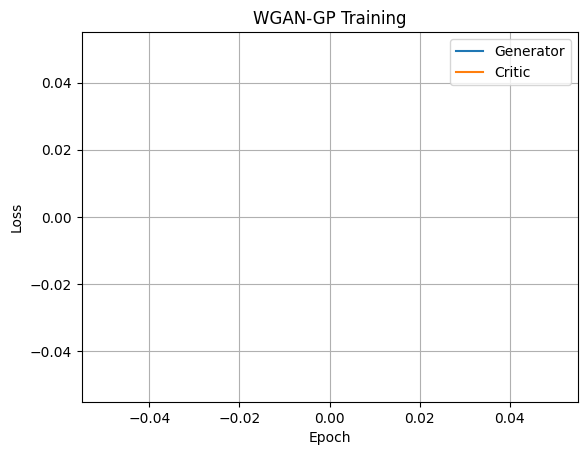

In [ ]:
plt.plot(g_loss_list,label="Generator")
plt.plot(d_loss_list,label="Critic")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("WGAN-GP Training")

plt.legend()

plt.grid()

plt.show()